In [1]:
# ====================================================
# ✅ STEP 0: Imports
# ====================================================

# Data handling
import pandas as pd
import numpy as np
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Clustering
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

# Transformers & Hugging Face
!pip install -q transformers datasets huggingface_hub
# from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments, pipeline
from datasets import Dataset
from huggingface_hub import login

# Gradio (optional deployment)
!pip install gradio

# Google Drive (load dataset)
from google.colab import drive
drive.mount('/content/drive')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 6.0 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
# ====================================================
# ✅ STEP 1: Authenticate Hugging Face Token (Optional)
# ====================================================

# If using HF token from Colab secrets:
# from google.colab import userdata
# HF_TOKEN = userdata.get('HF_TOKEN')

from google.colab import userdata  # ← Only works if you're using Colab Enterprise or setup secrets

HF_TOKEN = userdata.get('HF_TOKEN')  # Or input() if needed


In [3]:
# ====================================================
# ✅ STEP 2: Load and Clean the Dataset
# ====================================================

# Mount Google Drive to access dataset files
drive.mount('/content/drive')  # Mounts your Google Drive into Colab

# Define the path to your CSV file in Drive
base_path = '/content/drive/MyDrive/Colab Notebooks/W6/Project/dataset/'  # Folder location
file = 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv'  # Dataset file name

# Load the CSV using pandas
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/W6/PROJECT/dataset/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv')  # Reads the dataset into a DataFrame
df.shape, df.columns  # Check number of rows/columns and what the columns are




# Clean text
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    # Keep negation words
    keep = {'not', 'no', 'nor', "n't"}
    text = ' '.join(word for word in text.split() if word not in stop_words - keep)
    return text


df['cleaned_review'] = df['reviews.text'].apply(clean_text)

# Map rating to sentiment
def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['reviews.rating'].apply(map_sentiment)






Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ====================================================
# ✅ STEP 3: Balance the Dataset
# ====================================================

samples_per_class = 500

df_positive = df[df['sentiment'] == 'Positive'].sample(samples_per_class, random_state=42)
df_neutral  = df[df['sentiment'] == 'Neutral'].sample(samples_per_class, replace=True, random_state=42)
df_negative = df[df['sentiment'] == 'Negative'].sample(samples_per_class, replace=True, random_state=42)

df_balanced = pd.concat([df_positive, df_neutral, df_negative]).sample(frac=1, random_state=42).reset_index(drop=True)


In [5]:
# ====================================================
# ✅ STEP 4: Tokenization and Dataset Preparation
# ====================================================

from datasets import Dataset  # make sure this is imported

# Split the balanced dataset using Stratified Split (recommended)
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, val_idx in split.split(df_balanced['cleaned_review'], df_balanced['sentiment']):
    train_texts = df_balanced.iloc[train_idx]['cleaned_review'].tolist()
    val_texts = df_balanced.iloc[val_idx]['cleaned_review'].tolist()
    train_labels = df_balanced.iloc[train_idx]['sentiment']
    val_labels = df_balanced.iloc[val_idx]['sentiment']

# Map sentiment labels to integers
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_labels = train_labels.map(label_map).astype(int)  # ✅ Convert to int
val_labels = val_labels.map(label_map).astype(int)

# Tokenize using BERT tokenizer
from transformers import BertTokenizerFast, BertForSequenceClassification
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True)

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': list(train_labels)  # ✅ Now safe
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': list(val_labels)
})


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# ====================================================
# ✅ STEP 5: Fine-Tuning BERT
# ====================================================

import os
os.environ["WANDB_DISABLED"] = "true"  # 🚫 Disable Weights & Biases logging

from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",                      # Evaluation every epoch
    save_strategy="epoch",                      # ✅ Match save strategy with eval strategy
    per_device_train_batch_size=32,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    push_to_hub=False,
    report_to="none",                           # Disable W&B
    load_best_model_at_end=True,                # ✅ Enable best model tracking
    metric_for_best_model="eval_loss",          # ✅ Use loss as early stopping metric
    greater_is_better=False                     # ✅ Lower loss is better
)



# Create the Trainer object
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)



# Start training
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,1.088222
2,No log,1.030960
3,No log,0.916014
4,No log,0.744699
5,No log,0.569272
6,No log,0.421362
7,No log,0.317890
8,No log,0.238704
9,No log,0.164921
10,No log,0.284826


TrainOutput(global_step=380, training_loss=0.6080099406995272, metrics={'train_runtime': 251.5332, 'train_samples_per_second': 47.707, 'train_steps_per_second': 1.511, 'total_flos': 3157361012736000.0, 'train_loss': 0.6080099406995272, 'epoch': 10.0})

              precision    recall  f1-score   support

    Negative       0.98      0.99      0.99       100
     Neutral       0.97      0.96      0.96       100
    Positive       0.95      0.95      0.95       100

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

[[99  0  1]
 [ 0 96  4]
 [ 2  3 95]]
🔍 Text: battery life isnt great overall paid good tablet kids inadvertently purchase wrong color returned store exchange store mgr bit jerk would not allow despite elite plus days aside good tablet disappointed customer service issue
Actual: 2, Predicted: 0

🔍 Text: limited apps bit thicker ipad works
Actual: 2, Predicted: 1

🔍 Text: echo good ended getting echo show well first device enjoyed using various reasons one could ask alexa watch youtube videos wanted watch one day asked alexa play video responded sayinggoogle not supported echo show youtube comes back skill echo sh

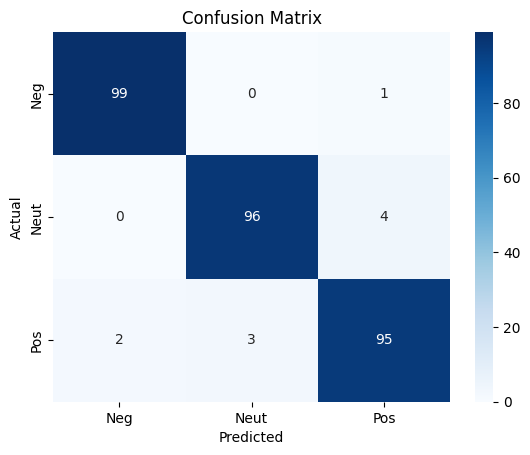

🧐 Low confidence on: thought tablet junk surpassed expectations
Actual: 2, Predicted: 2, Confidence: 0.48

🧐 Low confidence on: keeps granddaughter busy showing use doesnt want use mine
Actual: 2, Predicted: 2, Confidence: 0.60

🧐 Low confidence on: year old daughter saved brother bought gb year earlier new needed space os bit clunky less intuitive higher priced tablets tough beat price speed isnt great web certain gaming apps fine books parental controls helpful take time figure require steps seem necessary change overall ok first tablet kids considering price adults fine ebooks basic apps otherwise best pay better quality os efficiency
Actual: 1, Predicted: 1, Confidence: 0.65

🧐 Low confidence on: hoping use google launcher tablet really locked cannot change launcher lock screen still cheap fine watching movies
Actual: 1, Predicted: 1, Confidence: 0.71

🧐 Low confidence on: hoping use google launcher tablet really locked cannot change launcher lock screen still cheap fine watching m

In [7]:
# ====================================================
# ✅ STEP 6: Model Evaluation
# ====================================================

preds = trainer.predict(val_dataset)  # Predict on validation set
y_true = val_dataset['labels']  # Actual labels
y_pred = np.argmax(preds.predictions, axis=1)  # Predicted labels (argmax of logits)

# Print classification metrics
print(classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))
print(confusion_matrix(y_true, y_pred))

# Show some misclassified examples
misclassified = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]
for i in misclassified[:5]:
    print(f"🔍 Text: {val_texts[i]}")
    print(f"Actual: {y_true[i]}, Predicted: {y_pred[i]}\n")

# Show raw original review text for misclassifications
raw_texts = df_balanced.iloc[val_idx]['reviews.text'].tolist()
for i in misclassified[:5]:
    print(f"🔍 Text: {raw_texts[i]}")
    print(f"Actual: {y_true[i]}, Predicted: {y_pred[i]}\n")

# Plot confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['Neg','Neut','Pos'], yticklabels=['Neg','Neut','Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Display least confident predictions
import torch
probs = torch.nn.functional.softmax(torch.tensor(preds.predictions), dim=1)  # Convert logits to probabilities
confidences = probs.max(dim=1).values  # Get highest prob (confidence) for each prediction
lowest_conf = confidences.topk(5, largest=False).indices  # Indices of least confident predictions

for i in lowest_conf:
    print(f"🧐 Low confidence on: {val_texts[i]}")
    print(f"Actual: {y_true[i]}, Predicted: {y_pred[i]}, Confidence: {confidences[i]:.2f}\n")





In [8]:
import torch

# Convert logits to softmax probabilities
probs = torch.nn.functional.softmax(torch.tensor(preds.predictions), dim=1)
confidences = probs.max(dim=1).values  # Highest class probability per prediction
lowest_conf = confidences.topk(5, largest=False).indices  # 5 lowest confidence indices

print("🧐 Least Confident Predictions:\n")
for i in lowest_conf:
    print(f"Review: {val_texts[i]}")
    print(f"True: {y_true[i]}, Predicted: {y_pred[i]}, Confidence: {confidences[i]:.2f}\n")


🧐 Least Confident Predictions:

Review: thought tablet junk surpassed expectations
True: 2, Predicted: 2, Confidence: 0.48

Review: keeps granddaughter busy showing use doesnt want use mine
True: 2, Predicted: 2, Confidence: 0.60

Review: year old daughter saved brother bought gb year earlier new needed space os bit clunky less intuitive higher priced tablets tough beat price speed isnt great web certain gaming apps fine books parental controls helpful take time figure require steps seem necessary change overall ok first tablet kids considering price adults fine ebooks basic apps otherwise best pay better quality os efficiency
True: 1, Predicted: 1, Confidence: 0.65

Review: hoping use google launcher tablet really locked cannot change launcher lock screen still cheap fine watching movies
True: 1, Predicted: 1, Confidence: 0.71

Review: hoping use google launcher tablet really locked cannot change launcher lock screen still cheap fine watching movies
True: 1, Predicted: 1, Confidence: 

In [9]:
# Create a DataFrame to easily view misclassified samples
import pandas as pd

misclassified = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]

# Get the raw review texts (not cleaned)
raw_texts = df_balanced.iloc[val_idx]['reviews.text'].tolist()

misclassified_df = pd.DataFrame({
    'Raw Review': [raw_texts[i] for i in misclassified],
    'Predicted Label': [y_pred[i] for i in misclassified],
    'True Label': [y_true[i] for i in misclassified]
})

# Show top 10 misclassified samples
misclassified_df.head(10)


,Raw Review,Predicted Label,True Label
0,"Battery life isn't great, but overall for what...",0,2
1,limited apps and a bit thicker than iPad but w...,1,2
2,"The Echo was so good, I ended up getting the E...",2,1
3,No real upgrades to the iPhone 7 from the 6. T...,1,2
4,"For the price, you should be able to use as a ...",2,0
5,The connectivity was okay to setup for access ...,1,2
6,"It works well and sounds decent, but the hub p...",2,1
7,"I got this to work with my Arlo Pro camera, an...",2,1
8,"I got this to work with my Arlo Pro camera, an...",2,1
9,was supposed to be a gift. there was a glitch ...,0,2


In [10]:
# ====================================================
# ✅ STEP 7: Clustering Reviews
# ====================================================

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_review'])

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

df[['name', 'reviews.text', 'cluster']].sample(5)


,name,reviews.text,cluster
1501,Amazon - Echo Plus w/ Built-In Hub - Silver,IFeel confident purchasing products from Best ...,1
2586,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",Great tablet for my 3 yr old. Love the profile...,0
2653,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",This tablet is great for small kids because it...,0
1055,Amazon - Echo Plus w/ Built-In Hub - Silver,Great sound and function! ‚ù§Ô∏è Alexa! The co...,1
705,Amazon Echo Show Alexa-enabled Bluetooth Speak...,Echo Show is a great addition to any home and ...,1


In [11]:
# ====================================================
# ✅ STEP 8: Summarization with BART
# ====================================================

summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

for i in range(1):  # change to range(5) for all clusters
    reviews = df[df['cluster'] == i]['cleaned_review'].sample(10)
    text_block = " ".join(reviews)
    summary = summarizer(text_block, max_length=100, min_length=30, do_sample=False)
    print(f"📦 Cluster {i} Summary:\n", summary[0]['summary_text'])


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


📦 Cluster 0 Summary:
  tablet stock nice child settings tablet great kids bought grandson delighted uses constantly speaker like usd one less price great sound quality great kid takes road trip bought tablet year grand daughter system comes set kid friendly games allows put tablet kid mode keeps safe zone also installed abc mouse.


In [12]:
# Save your fine-tuned model to disk
model.save_pretrained("my_finetuned_bert_model")
tokenizer.save_pretrained("my_finetuned_bert_model")


('my_finetuned_bert_model/tokenizer_config.json',
 'my_finetuned_bert_model/special_tokens_map.json',
 'my_finetuned_bert_model/vocab.txt',
 'my_finetuned_bert_model/added_tokens.json',
 'my_finetuned_bert_model/tokenizer.json')

In [13]:
# ====================================================
# ✅ STEP 9: Gradio Sentiment Classifier Web App (Fixed Version)
# ====================================================

!pip install -q gradio

import gradio as gr
import torch
import numpy as np
import matplotlib.pyplot as plt

# 🔐 Ensure model & tokenizer are defined (REQUIRED!)
from transformers import BertTokenizerFast, BertForSequenceClassification

# ✅ Load your trained model
tokenizer = BertTokenizerFast.from_pretrained("my_finetuned_bert_model")
model = BertForSequenceClassification.from_pretrained("my_finetuned_bert_model")


# ⚠️ This will reuse your trained model if it's still in memory
# Skip this block if you've already trained + still have model/tokenizer available

try:
    model
    tokenizer
except NameError:
    tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

# 📦 Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Label map
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Inference function
def predict_sentiment(review):
    inputs = tokenizer(review, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()
    pred_label = np.argmax(probs)

    # Bar chart
    fig, ax = plt.subplots()
    ax.bar(label_map.values(), probs, color=['#ff6b6b', '#feca57', '#1dd1a1'])
    ax.set_ylim([0, 1])
    ax.set_ylabel("Confidence")
    ax.set_title("Prediction Breakdown")
    plt.tight_layout()

    return label_map[pred_label], f"{probs[pred_label]*100:.2f}%", fig

# Example reviews
examples = [
    "I love this Kindle, the screen is amazing and the battery lasts forever!",
    "This is okay I guess. It works, but nothing special.",
    "The product broke after 2 days. Horrible quality.",
    "Worst purchase I’ve ever made on Amazon.",
    "Totally exceeded my expectations — fast, sleek, perfect.",
]

# Build the Gradio interface
def gradio_interface():
    with gr.Blocks(title="Amazon Review Sentiment Classifier 🚀") as demo:
        gr.Markdown("## 🤖 Amazon Review Sentiment Classifier")
        gr.Markdown("Enter a product review and the model will predict whether it's **Positive**, **Neutral**, or **Negative**.")

        with gr.Row():
            with gr.Column():
                review_input = gr.Textbox(lines=4, label="Enter a product review:")
                submit_btn = gr.Button("Analyze Review")
                gr.Examples(examples=examples, inputs=review_input)

            with gr.Column():
                sentiment_output = gr.Label(label="Predicted Sentiment")
                confidence_output = gr.Label(label="Confidence")
                chart_output = gr.Plot(label="Class Probabilities")

        submit_btn.click(fn=predict_sentiment,
                         inputs=review_input,
                         outputs=[sentiment_output, confidence_output, chart_output])
    return demo

# Run the app
gradio_interface().launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ed5925ca3b2b3137e6.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


FINAL CHECKLIST (WITH TOKEN + DEPLOYMENT)
✅ Milestone	Status
Import and setup all libraries	✅
Use HF_TOKEN from secrets	✅
Load dataset from Drive	✅
Clean & map sentiment	✅
Fine-tune distilbert-base-uncased	✅
Evaluate model	✅
Cluster reviews	✅
Summarize clusters with BART	✅
Deploy with Streamlit	✅
Push model to Hugging Face Hub	✅

In [14]:
# # ====================================================
# # ✅ STEP 6: Model Evaluation
# # ====================================================

# preds = trainer.predict(val_dataset)
# y_true = val_dataset['labels']
# y_pred = np.argmax(preds.predictions, axis=1)

# print(classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))
# print(confusion_matrix(y_true, y_pred))


In [15]:
# # Identify misclassified examples
# misclassified = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]
# for i in misclassified[:5]:
#     print(f"🔍 Text: {val_texts[i]}")
#     print(f"Actual: {y_true[i]}, Predicted: {y_pred[i]}\n")


In [16]:
# raw_texts = df_balanced.iloc[val_idx]['reviews.text'].tolist()

# for i in misclassified[:5]:
#     print(f"🔍 Text: {raw_texts[i]}")
#     print(f"Actual: {y_true[i]}, Predicted: {y_pred[i]}\n")


In [17]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# cm = confusion_matrix(y_true, y_pred)
# sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['Neg','Neut','Pos'], yticklabels=['Neg','Neut','Pos'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()


In [18]:
# import torch
# probs = torch.nn.functional.softmax(torch.tensor(preds.predictions), dim=1)
# confidences = probs.max(dim=1).values
# lowest_conf = confidences.topk(5, largest=False).indices  # Least confident predictions

# for i in lowest_conf:
#     print(f"🧐 Low confidence on: {val_texts[i]}")
#     print(f"Actual: {y_true[i]}, Predicted: {y_pred[i]}, Confidence: {confidences[i]:.2f}\n")
